# Universal Adversarial Perturbations: One Noise Pattern to Fool Many Images

Every attack elsewhere in this repo optimizes a perturbation for a single image. Moosavi-Dezfooli et al. (2017, *"Universal Adversarial Perturbations"*) ask a more surprising question: does a single, fixed perturbation exist that fools a network on a large fraction of *natural images it has never seen*, added unmodified to whatever image comes along? The existence of such a perturbation is a stronger and more unsettling statement about a model's vulnerability than any single-image attack, it says the decision boundary has a shared "blind spot" direction, not just many unrelated per-image weaknesses.

The algorithm builds the perturbation iteratively: walk through a set of training images, and whenever the current universal perturbation `v` is not already enough to fool a given image, use DeepFool to find the *minimal extra push* needed, add that push to `v`, and project `v` back into an $L_\infty$ ball of radius $\xi$ so it never grows past the target budget. Repeating this over the training set for a few passes converges to a `v` that fools most of it, and, if the effect is real and not overfitting to those specific images, a comparable fraction of a completely different, held-out set too.

In [1]:
import tensorflow as tf
import numpy as np
import glob
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

from advml_vision.attacks import deepfool_attack

np.random.seed(0)
tf.random.set_seed(0)

### Setup: One Model, a Train/Test Split of the Sample Bank
Scoped to a single CNN for this first pass (MobileNetV2), the same model used as the first entry in
`models_dict` throughout the repo. 30 images build the universal perturbation; a disjoint 20 check
whether it actually generalizes, not just overfits to the images it was built from.

In [2]:
model = MobileNetV2(weights='imagenet')
model.trainable = False
CLIP_MIN, CLIP_MAX = -1.0, 1.0
TARGET_SIZE = (224, 224)

def load_and_preprocess_image(img_path):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, TARGET_SIZE)
    img = preprocess_input(img)
    return tf.expand_dims(img, axis=0)

all_paths = sorted(glob.glob('../../images/miniimagenet_random_100/*.*'))
TRAIN_PATHS = all_paths[:30]
TEST_PATHS = all_paths[30:50]
print(f"{len(TRAIN_PATHS)} images to build the universal perturbation, {len(TEST_PATHS)} held out to test generalization")

30 images to build the universal perturbation, 20 held out to test generalization


### Building the Universal Perturbation
$\xi = 0.1$ ($L_\infty$ budget, larger than the single-image $\varepsilon=0.05$ used elsewhere in
this repo since one perturbation now has to work across many different images, a harder job).
`DEEPFOOL_NUM_CLASSES=10` and `DEEPFOOL_MAX_ITER=20` match the reduced budget already used for
DeepFool at scale in `defenses/04_adversarial_training.ipynb`, for the same per-image cost reasons.

In [3]:
XI = 0.1
MAX_PASSES = 5
DEEPFOOL_NUM_CLASSES = 10
DEEPFOOL_MAX_ITER = 20

v = np.zeros((1, *TARGET_SIZE, 3), dtype=np.float32)
fooling_rate_history = []

for pass_num in range(MAX_PASSES):
    for img_path in TRAIN_PATHS:
        x = load_and_preprocess_image(img_path)
        true_idx = int(tf.argmax(model(x, training=False)[0]))

        perturbed = tf.clip_by_value(x + v, CLIP_MIN, CLIP_MAX)
        current_pred = int(tf.argmax(model(perturbed, training=False)[0]))

        if current_pred == true_idx:  # v does not yet fool this image - find the minimal extra push
            adv = deepfool_attack(perturbed, model, CLIP_MIN, CLIP_MAX,
                                   num_classes=DEEPFOOL_NUM_CLASSES, max_iter=DEEPFOOL_MAX_ITER)
            dr = (adv - perturbed).numpy()
            v = v + dr
            v = np.clip(v, -XI, XI)  # project back into the L_infinity ball of radius XI

    fooled = sum(
        int(tf.argmax(model(tf.clip_by_value(load_and_preprocess_image(p) + v, CLIP_MIN, CLIP_MAX), training=False)[0]))
        != int(tf.argmax(model(load_and_preprocess_image(p), training=False)[0]))
        for p in TRAIN_PATHS
    )
    fooling_rate = fooled / len(TRAIN_PATHS)
    fooling_rate_history.append(fooling_rate)
    print(f"Pass {pass_num + 1}/{MAX_PASSES} - train fooling rate: {fooling_rate * 100:.1f}%")

np.save('universal_perturbation.npy', v)

Pass 1/5 - train fooling rate: 60.0%


Pass 2/5 - train fooling rate: 86.7%


Pass 3/5 - train fooling rate: 96.7%


Pass 4/5 - train fooling rate: 93.3%


Pass 5/5 - train fooling rate: 96.7%


### Does It Generalize? Evaluating on Held-Out Images
The whole point of a *universal* perturbation is that it was never fit to these 20 images at all;
if the fooling rate here is comparably high, the network really does have a shared blind-spot
direction, not just 30 memorized weaknesses.

Held-out fooling rate: 40.0% (8/20 unseen images)
Train fooling rate (final pass): 96.7%


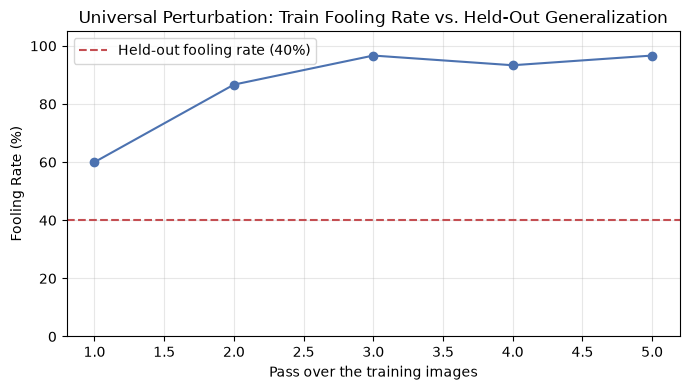

In [4]:
test_fooled = 0
for p in TEST_PATHS:
    x = load_and_preprocess_image(p)
    true_idx = int(tf.argmax(model(x, training=False)[0]))
    perturbed = tf.clip_by_value(x + v, CLIP_MIN, CLIP_MAX)
    pred_idx = int(tf.argmax(model(perturbed, training=False)[0]))
    if pred_idx != true_idx:
        test_fooled += 1

test_fooling_rate = test_fooled / len(TEST_PATHS)
print(f"Held-out fooling rate: {test_fooling_rate * 100:.1f}% ({test_fooled}/{len(TEST_PATHS)} unseen images)")
print(f"Train fooling rate (final pass): {fooling_rate_history[-1] * 100:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(fooling_rate_history) + 1), [f * 100 for f in fooling_rate_history], 'o-', color='#4C72B0')
plt.axhline(test_fooling_rate * 100, color='#C44E52', linestyle='--', label=f'Held-out fooling rate ({test_fooling_rate*100:.0f}%)')
plt.xlabel('Pass over the training images')
plt.ylabel('Fooling Rate (%)')
plt.title('Universal Perturbation: Train Fooling Rate vs. Held-Out Generalization')
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### What Does a Universal Perturbation Actually Look Like?
Unlike a per-image FGSM/PGD perturbation, which looks like structured noise specific to that one
image's gradient, a universal perturbation is the same fixed pattern added to every image, visible
on its own without any input image at all.

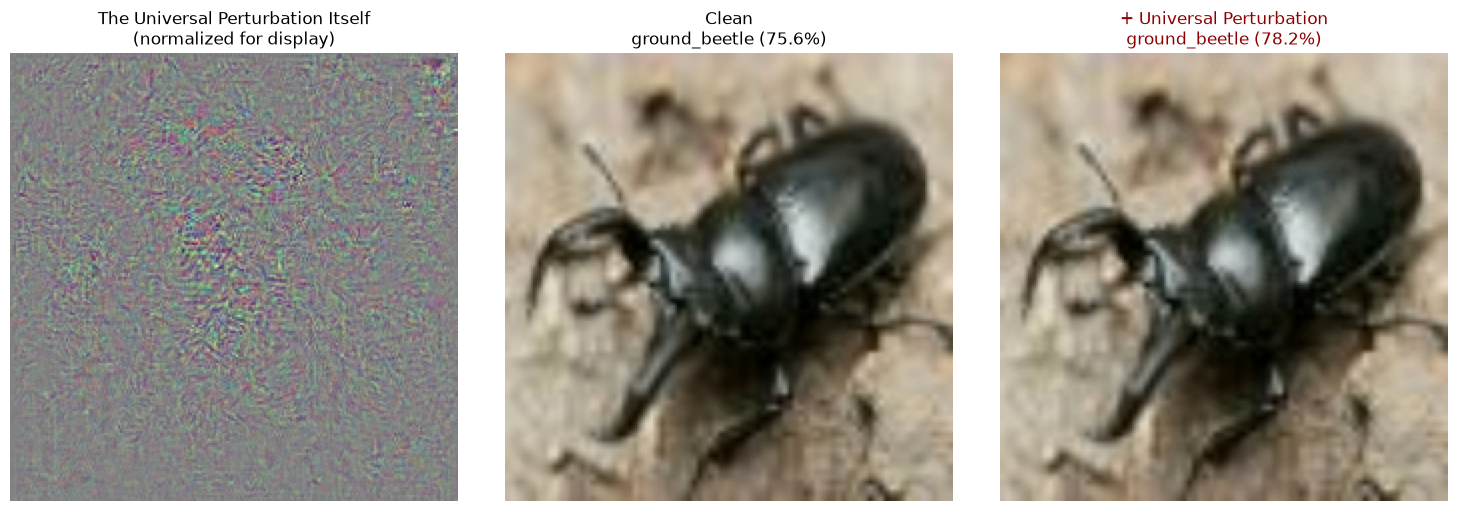

In [5]:
v_display = (v[0] - v[0].min()) / (v[0].max() - v[0].min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(v_display)
axes[0].set_title('The Universal Perturbation Itself\n(normalized for display)')
axes[0].axis('off')

example_path = TEST_PATHS[0]
x_clean = load_and_preprocess_image(example_path)
x_adv = tf.clip_by_value(x_clean + v, CLIP_MIN, CLIP_MAX)
clean_pred = decode_predictions(model(x_clean, training=False).numpy(), top=1)[0][0]
adv_pred = decode_predictions(model(x_adv, training=False).numpy(), top=1)[0][0]

axes[1].imshow((x_clean[0].numpy() + 1) / 2)
axes[1].set_title(f'Clean\n{clean_pred[1]} ({clean_pred[2]*100:.1f}%)')
axes[1].axis('off')

axes[2].imshow(np.clip((x_adv[0].numpy() + 1) / 2, 0, 1))
axes[2].set_title(f'+ Universal Perturbation\n{adv_pred[1]} ({adv_pred[2]*100:.1f}%)', color='darkred')
axes[2].axis('off')

plt.tight_layout()
plt.show()